<a href="https://www.kaggle.com/code/sonawanelalitsunil/predicting-podcast-eda?scriptVersionId=236544376" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e4/sample_submission.csv
/kaggle/input/playground-series-s5e4/train.csv
/kaggle/input/playground-series-s5e4/test.csv


## Title : Predicting Podcast Listening Time

### Description:
This project focuses on predicting the amount of time a user spends listening to podcasts based on various factors such as user demographics, listening habits, device type, and content preferences. By analyzing historical listening data, user interactions, and podcast features, machine learning models can be trained to predict future listening behavior. The objective is to optimize recommendations, improve user experience, and enhance podcast content strategies. This prediction model can be useful for podcast platforms aiming to personalize content and maximize user engagement.










## Import dataset

In [2]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')
sample_submission_df = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

In [3]:
print("Train DataFrame:")
print(train_df.head())

Train DataFrame:
   id     Podcast_Name Episode_Title  Episode_Length_minutes       Genre  \
0   0  Mystery Matters    Episode 98                     NaN  True Crime   
1   1    Joke Junction    Episode 26                  119.80      Comedy   
2   2   Study Sessions    Episode 16                   73.90   Education   
3   3   Digital Digest    Episode 45                   67.17  Technology   
4   4      Mind & Body    Episode 86                  110.51      Health   

   Host_Popularity_percentage Publication_Day Publication_Time  \
0                       74.81        Thursday            Night   
1                       66.95        Saturday        Afternoon   
2                       69.97         Tuesday          Evening   
3                       57.22          Monday          Morning   
4                       80.07          Monday        Afternoon   

   Guest_Popularity_percentage  Number_of_Ads Episode_Sentiment  \
0                          NaN            0.0          Positiv

In [4]:
print("\nTest DataFrame:")
print(test_df.head())



Test DataFrame:
       id         Podcast_Name Episode_Title  Episode_Length_minutes  \
0  750000  Educational Nuggets    Episode 73                   78.96   
1  750001          Sound Waves    Episode 23                   27.87   
2  750002        Joke Junction    Episode 11                   69.10   
3  750003        Comedy Corner    Episode 73                  115.39   
4  750004         Life Lessons    Episode 50                   72.32   

       Genre  Host_Popularity_percentage Publication_Day Publication_Time  \
0  Education                       38.11        Saturday          Evening   
1      Music                       71.29          Sunday          Morning   
2     Comedy                       67.89          Friday          Evening   
3     Comedy                       23.40          Sunday          Morning   
4  Lifestyle                       58.10       Wednesday          Morning   

   Guest_Popularity_percentage  Number_of_Ads Episode_Sentiment  
0                    

In [5]:
print("\nSample Submission DataFrame:")
print(sample_submission_df.head())



Sample Submission DataFrame:
       id  Listening_Time_minutes
0  750000                  45.437
1  750001                  45.437
2  750002                  45.437
3  750003                  45.437
4  750004                  45.437


In [6]:
# Additional exploration - Checking the columns and data types
print("\nTrain DataFrame Info:")
print(train_df.info())



Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)


In [7]:
print("\nTest DataFrame Info:")
print(test_df.info())



Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB
None


In [8]:
print("\nSample Submission DataFrame Info:")
print(sample_submission_df.info())


Sample Submission DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 2 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      250000 non-null  int64  
 1   Listening_Time_minutes  250000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 3.8 MB
None


In [9]:
print("Missing Values in Train DataFrame:")
print(train_df.isnull().sum())

Missing Values in Train DataFrame:
id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64


In [10]:
print("\nMissing Values in Test DataFrame:")
print(test_df.isnull().sum())


Missing Values in Test DataFrame:
id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64


In [11]:
print("\nTrain DataFrame Summary Statistics:")
print(train_df.describe())


Train DataFrame Summary Statistics:
                  id  Episode_Length_minutes  Host_Popularity_percentage  \
count  750000.000000           662907.000000               750000.000000   
mean   374999.500000               64.504738                   59.859901   
std    216506.495284               32.969603                   22.873098   
min         0.000000                0.000000                    1.300000   
25%    187499.750000               35.730000                   39.410000   
50%    374999.500000               63.840000                   60.050000   
75%    562499.250000               94.070000                   79.530000   
max    749999.000000              325.240000                  119.460000   

       Guest_Popularity_percentage  Number_of_Ads  Listening_Time_minutes  
count                603970.000000  749999.000000           750000.000000  
mean                     52.236449       1.348855               45.437406  
std                      28.451241       1.151130 

In [12]:
print("\nTest DataFrame Summary Statistics:")
print(test_df.describe())


Test DataFrame Summary Statistics:
                  id  Episode_Length_minutes  Host_Popularity_percentage  \
count  250000.000000            2.212640e+05               250000.000000   
mean   874999.500000            4.192987e+02                   59.716491   
std     72168.927986            1.668545e+05                   22.880028   
min    750000.000000            2.470000e+00                    2.490000   
25%    812499.750000            3.578000e+01                   39.250000   
50%    874999.500000            6.397000e+01                   59.900000   
75%    937499.250000            9.415000e+01                   79.390000   
max    999999.000000            7.848626e+07                  117.760000   

       Guest_Popularity_percentage  Number_of_Ads  
count                201168.000000  250000.000000  
mean                     52.192796       1.355852  
std                      28.445034       4.274399  
min                       0.000000       0.000000  
25%                

In [13]:
print("\nDuplicate Rows in Train DataFrame:")
print(train_df.duplicated().sum())


Duplicate Rows in Train DataFrame:
0


In [14]:
print("\nDuplicate Rows in Test DataFrame:")
print(test_df.duplicated().sum())


Duplicate Rows in Test DataFrame:
0


In [15]:
print("\nTrain DataFrame Data Types:")
print(train_df.dtypes)


Train DataFrame Data Types:
id                               int64
Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
Listening_Time_minutes         float64
dtype: object


In [16]:
train_df.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment', 'Listening_Time_minutes'],
      dtype='object')

## Train - Data visualizations

Text(0, 0.5, 'Frequency')

<Figure size 1200x600 with 0 Axes>

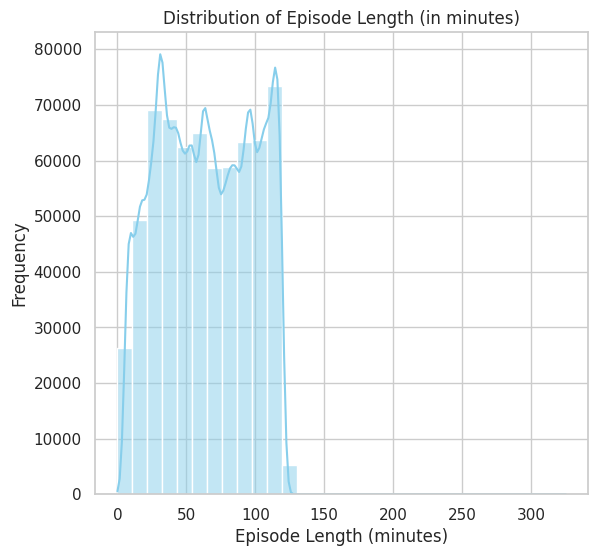

In [17]:
# Set up visualization settings
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Distribution of Episode Length and Listening Time
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_df['Episode_Length_minutes'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Episode Length (in minutes)')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Frequency')


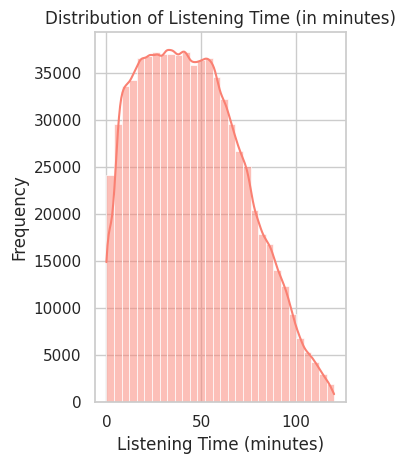

In [18]:
plt.subplot(1, 2, 2)
sns.histplot(train_df['Listening_Time_minutes'], kde=True, color='salmon', bins=30)
plt.title('Distribution of Listening Time (in minutes)')
plt.xlabel('Listening Time (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

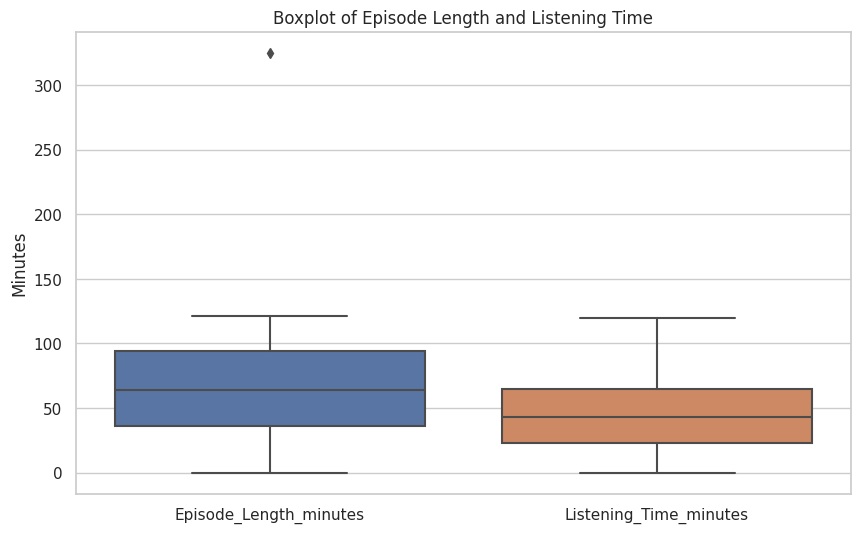

In [19]:
# 2. Boxplot for Outliers in Episode Length and Listening Time
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df[['Episode_Length_minutes', 'Listening_Time_minutes']])
plt.title('Boxplot of Episode Length and Listening Time')
plt.ylabel('Minutes')
plt.show()

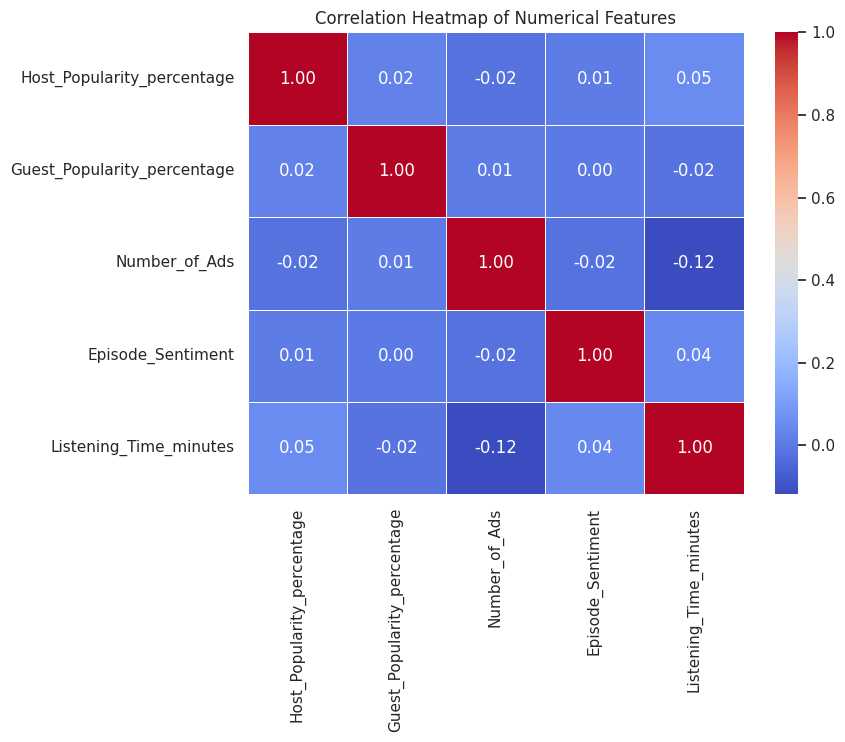

In [20]:
sentiment_mapping = {
    'Positive': 1,
    'Neutral': 0,
    'Negative': -1
}
train_df['Episode_Sentiment'] = train_df['Episode_Sentiment'].map(sentiment_mapping)

# Now, proceed with the correlation matrix
corr_matrix = train_df[['Host_Popularity_percentage', 'Guest_Popularity_percentage', 
                        'Number_of_Ads', 'Episode_Sentiment', 'Listening_Time_minutes']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

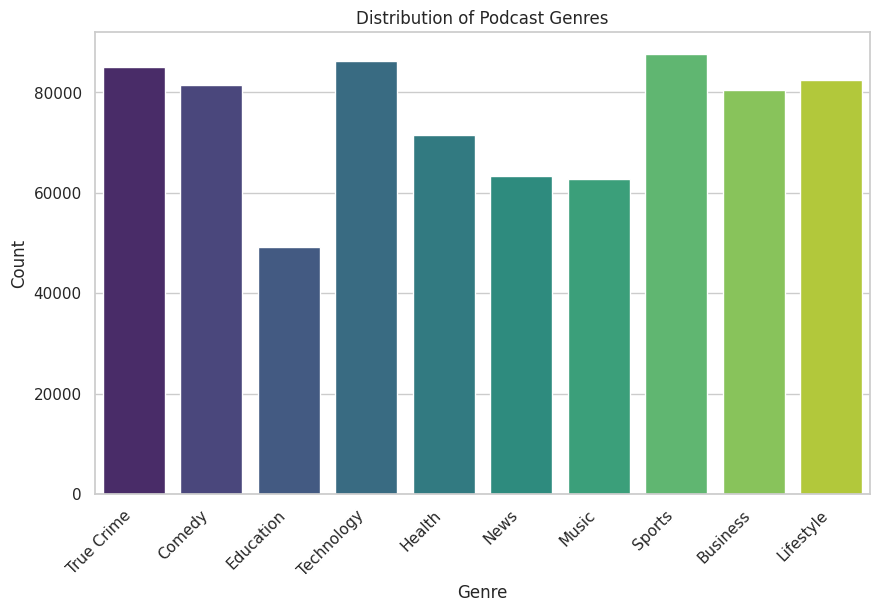

In [21]:
# 4. Genre Distribution (Countplot)
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='Genre', palette='viridis')
plt.title('Distribution of Podcast Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

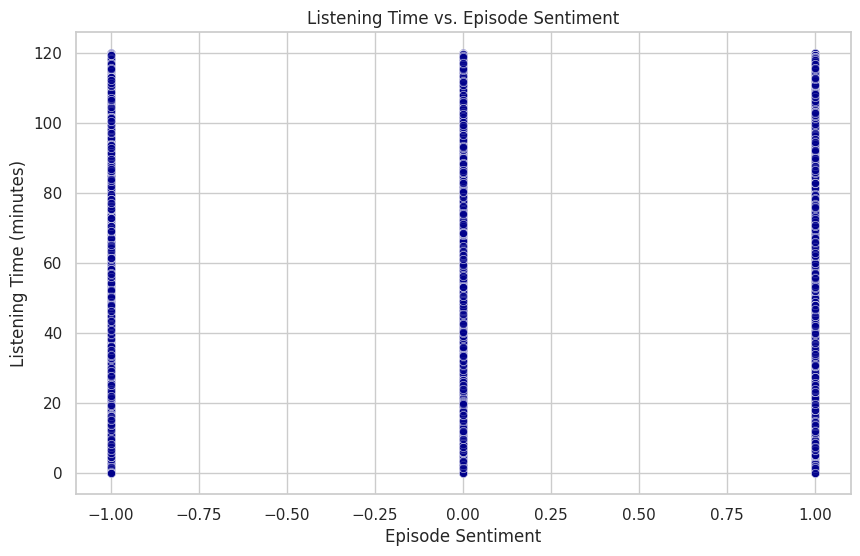

In [22]:
# 5. Listening Time vs. Episode Sentiment (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='Episode_Sentiment', y='Listening_Time_minutes', color='darkblue', alpha=0.7)
plt.title('Listening Time vs. Episode Sentiment')
plt.xlabel('Episode Sentiment')
plt.ylabel('Listening Time (minutes)')
plt.show()


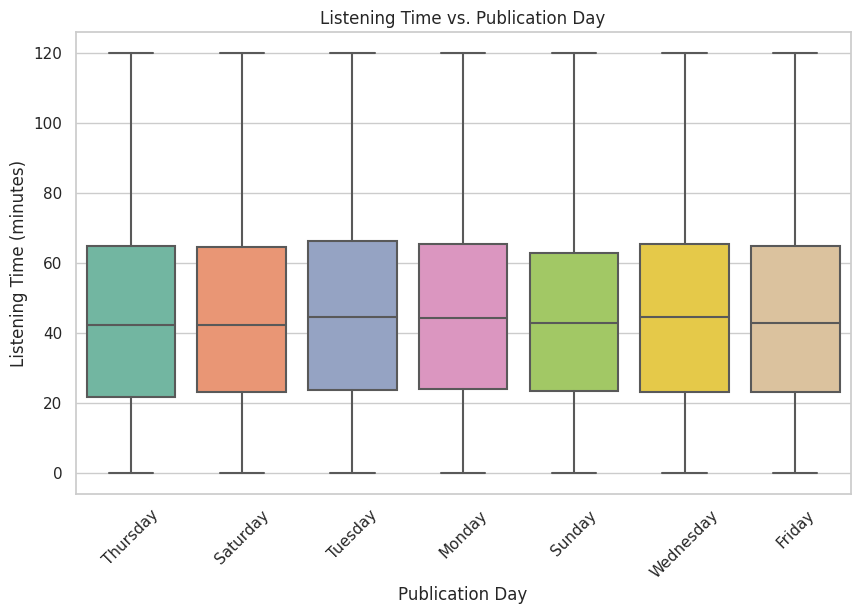

In [23]:
# 6. Listening Time vs. Publication Day (Time-based Analysis)
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='Publication_Day', y='Listening_Time_minutes', palette='Set2')
plt.title('Listening Time vs. Publication Day')
plt.xlabel('Publication Day')
plt.ylabel('Listening Time (minutes)')
plt.xticks(rotation=45)
plt.show()

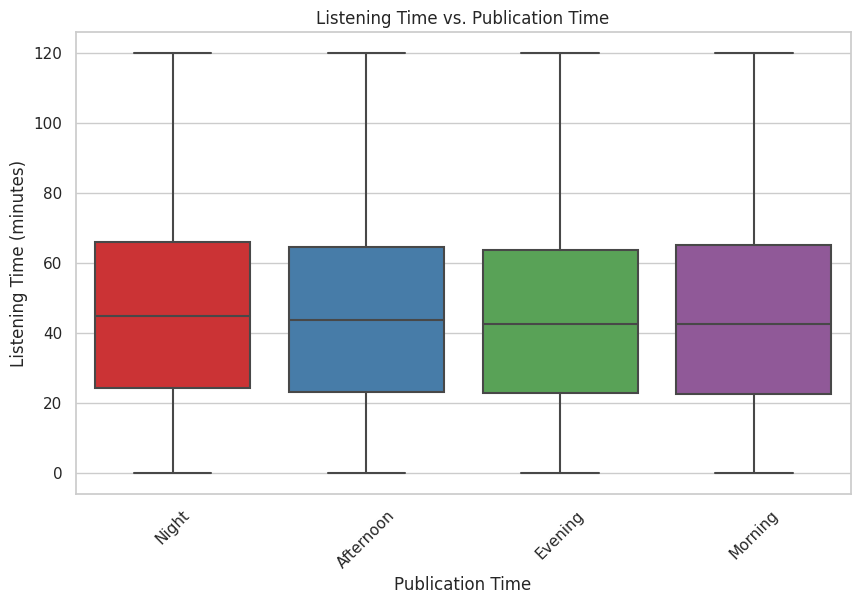

In [24]:
# 7. Listening Time vs. Publication Time (Time-based Analysis)
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='Publication_Time', y='Listening_Time_minutes', palette='Set1')
plt.title('Listening Time vs. Publication Time')
plt.xlabel('Publication Time')
plt.ylabel('Listening Time (minutes)')
plt.xticks(rotation=45)
plt.show()

## Test visualizations

In [25]:
test_df.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment'],
      dtype='object')

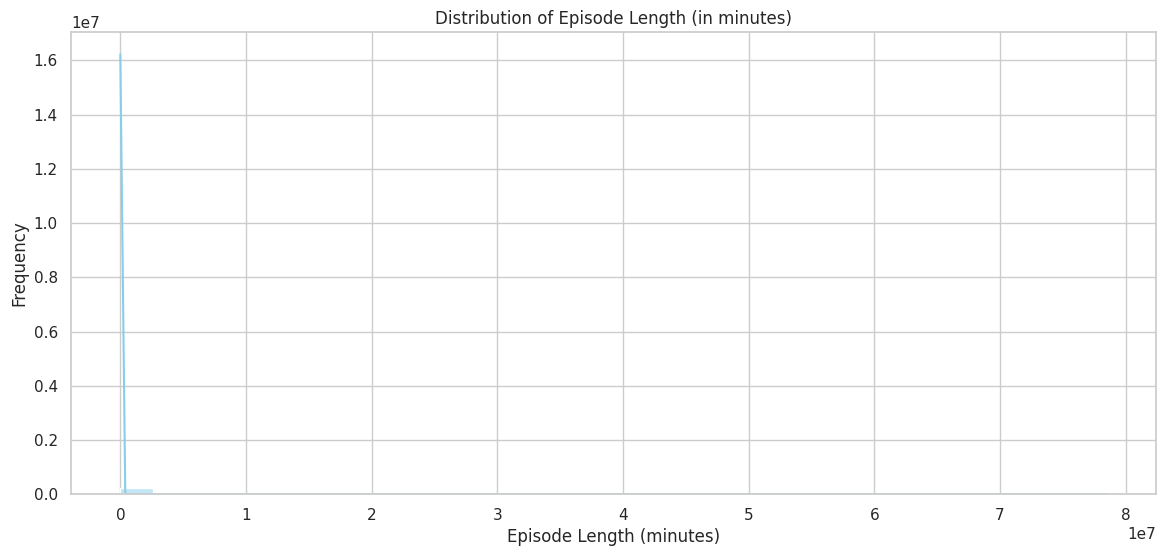

In [26]:
plt.figure(figsize=(14, 6))
sns.histplot(test_df['Episode_Length_minutes'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Episode Length (in minutes)')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Frequency')
plt.show()


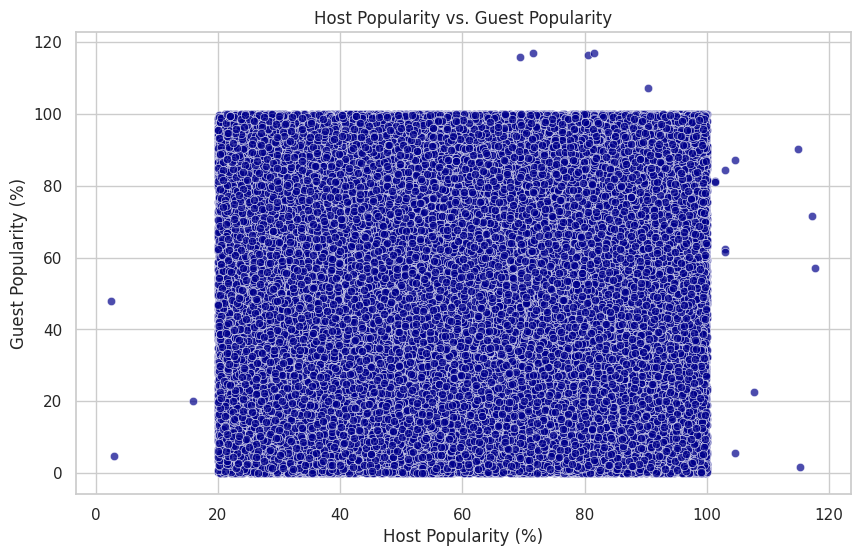

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_df, x='Host_Popularity_percentage', y='Guest_Popularity_percentage', color='darkblue', alpha=0.7)
plt.title('Host Popularity vs. Guest Popularity')
plt.xlabel('Host Popularity (%)')
plt.ylabel('Guest Popularity (%)')
plt.show()


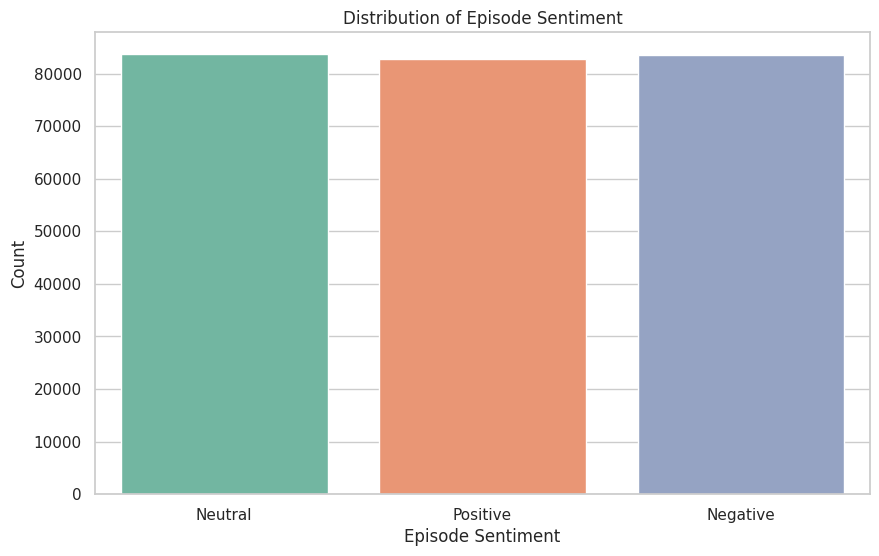

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=test_df, x='Episode_Sentiment', palette='Set2')
plt.title('Distribution of Episode Sentiment')
plt.xlabel('Episode Sentiment')
plt.ylabel('Count')
plt.show()

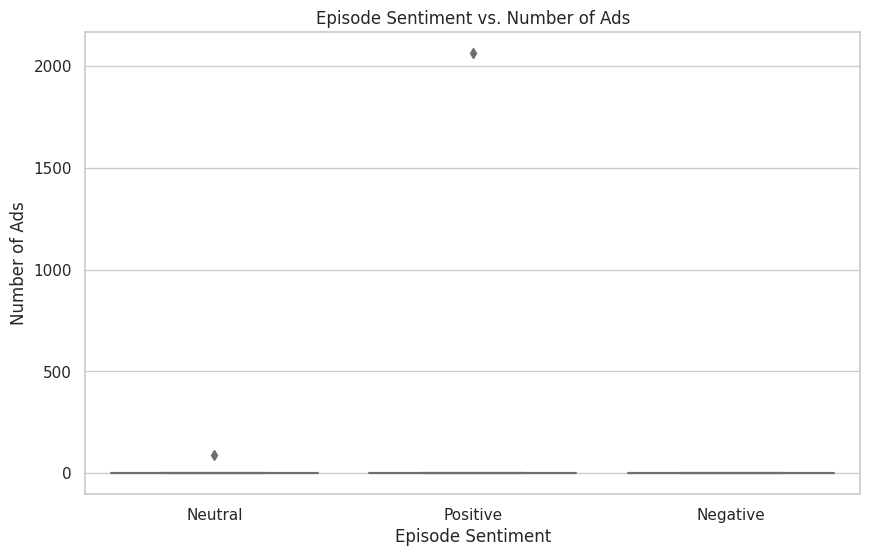

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=test_df, x='Episode_Sentiment', y='Number_of_Ads', palette='coolwarm')
plt.title('Episode Sentiment vs. Number of Ads')
plt.xlabel('Episode Sentiment')
plt.ylabel('Number of Ads')
plt.show()

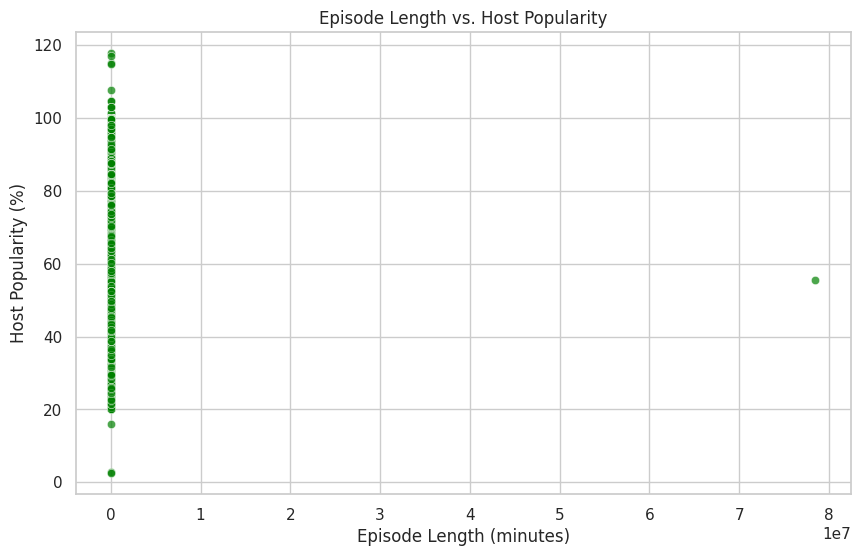

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_df, x='Episode_Length_minutes', y='Host_Popularity_percentage', color='green', alpha=0.7)
plt.title('Episode Length vs. Host Popularity')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Host Popularity (%)')
plt.show()

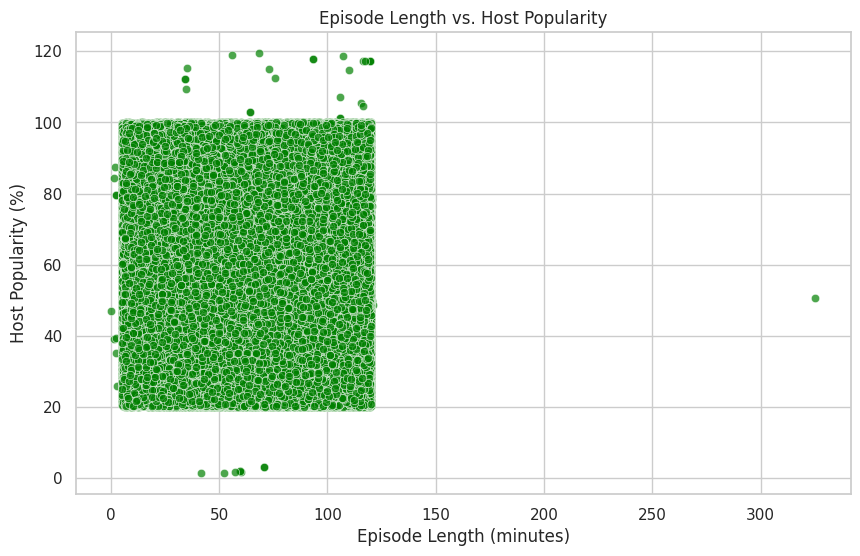

In [31]:
# 6. Episode Length vs. Host Popularity (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='Episode_Length_minutes', y='Host_Popularity_percentage', color='green', alpha=0.7)
plt.title('Episode Length vs. Host Popularity')
plt.xlabel('Episode Length (minutes)')
plt.ylabel('Host Popularity (%)')
plt.show()

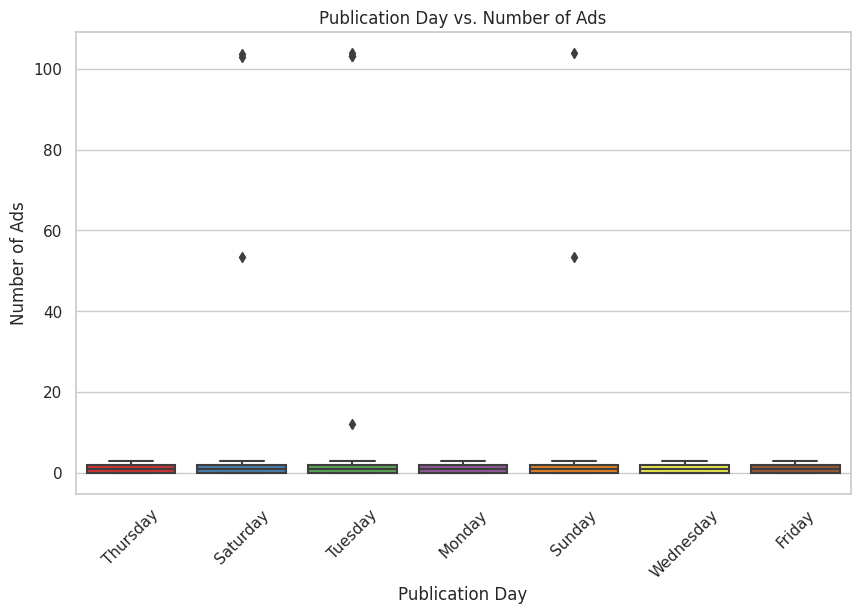

In [32]:
# 7. Publication Day vs. Number of Ads (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='Publication_Day', y='Number_of_Ads', palette='Set1')
plt.title('Publication Day vs. Number of Ads')
plt.xlabel('Publication Day')
plt.ylabel('Number of Ads')
plt.xticks(rotation=45)
plt.show()

## EDA

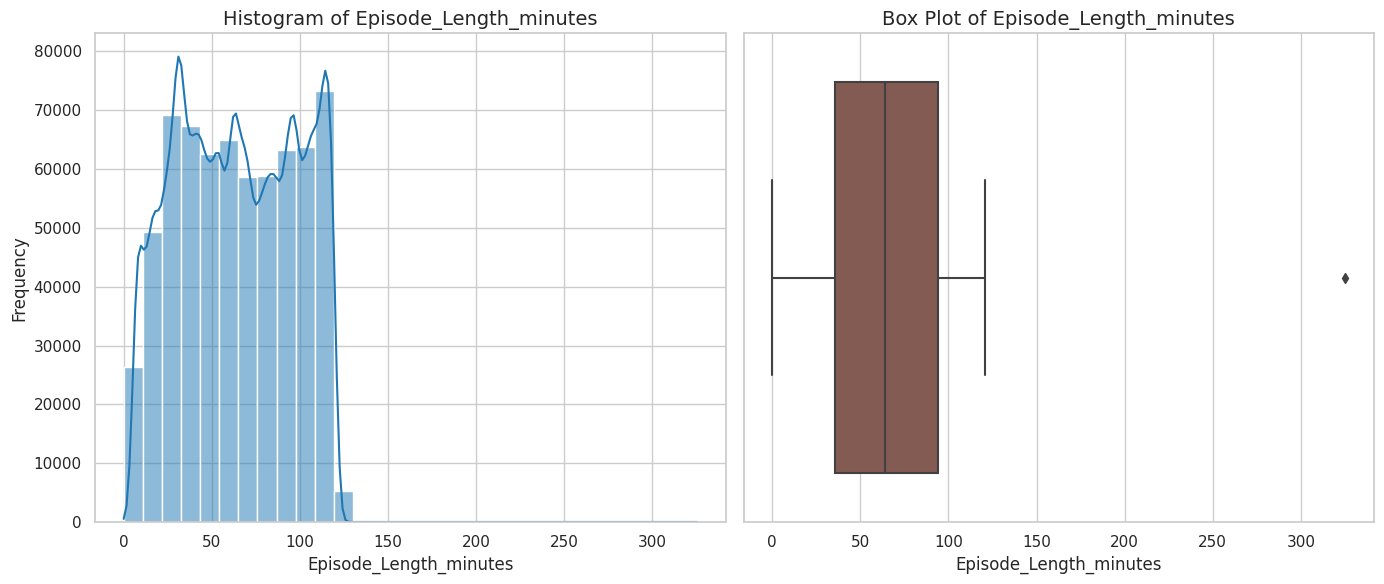


Statistics for Episode_Length_minutes:
Skewness: -0.00
Number of Missing Values: 87093


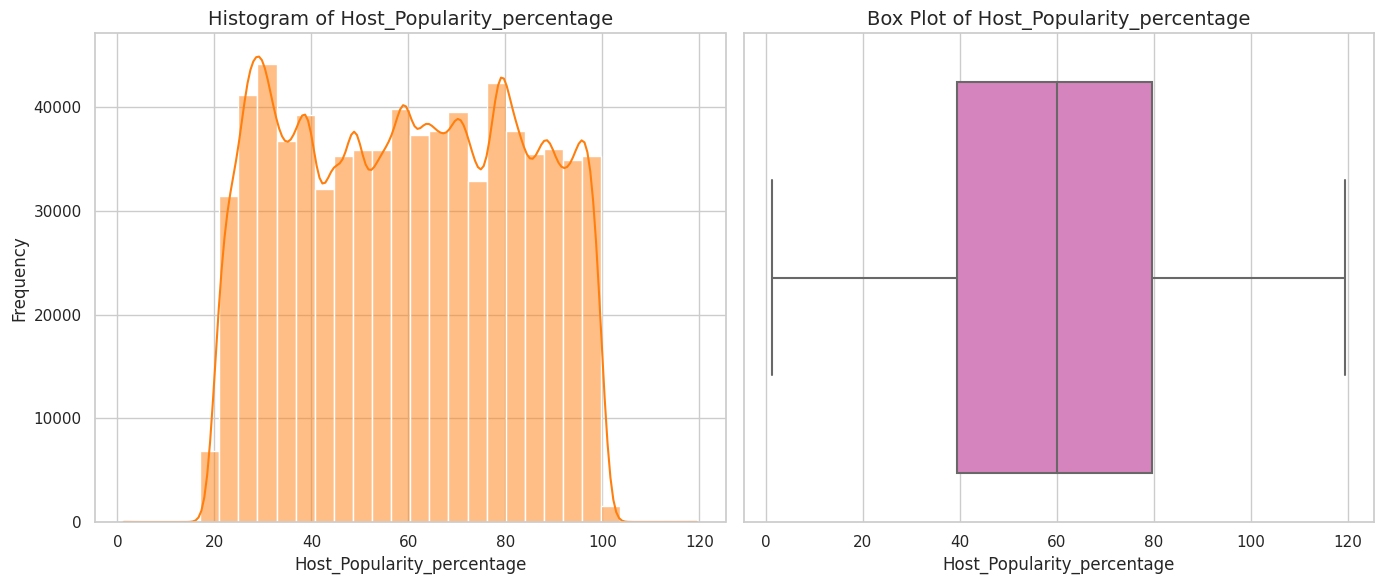


Statistics for Host_Popularity_percentage:
Skewness: 0.00
Number of Missing Values: 0


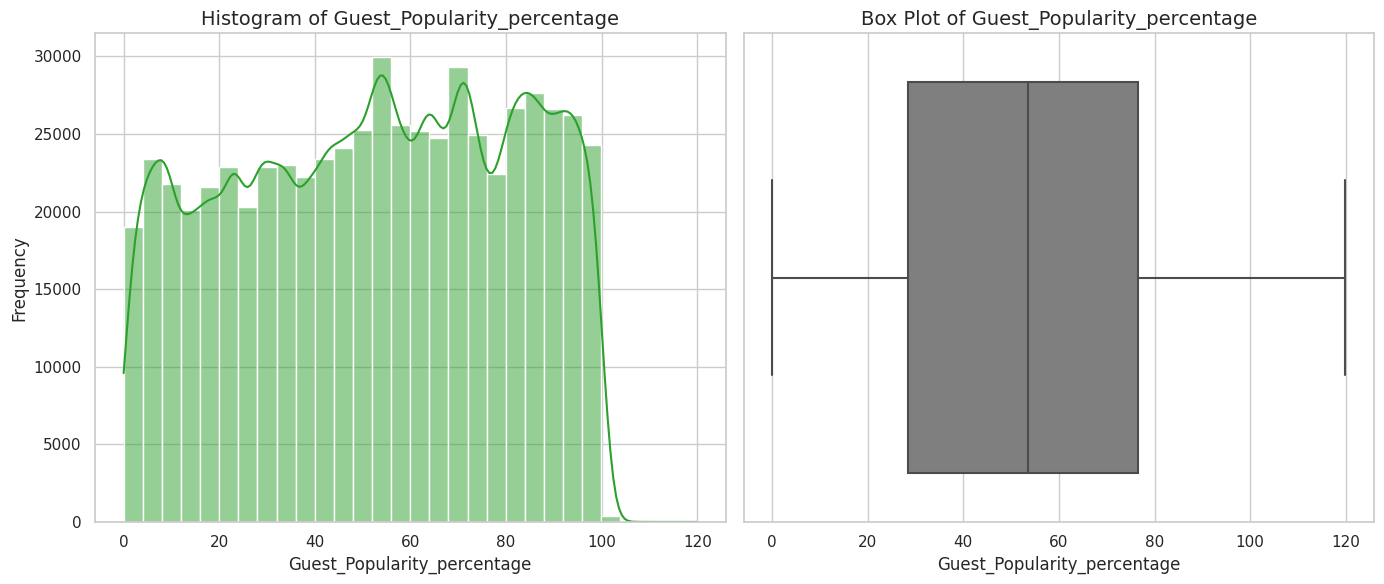


Statistics for Guest_Popularity_percentage:
Skewness: -0.11
Number of Missing Values: 146030


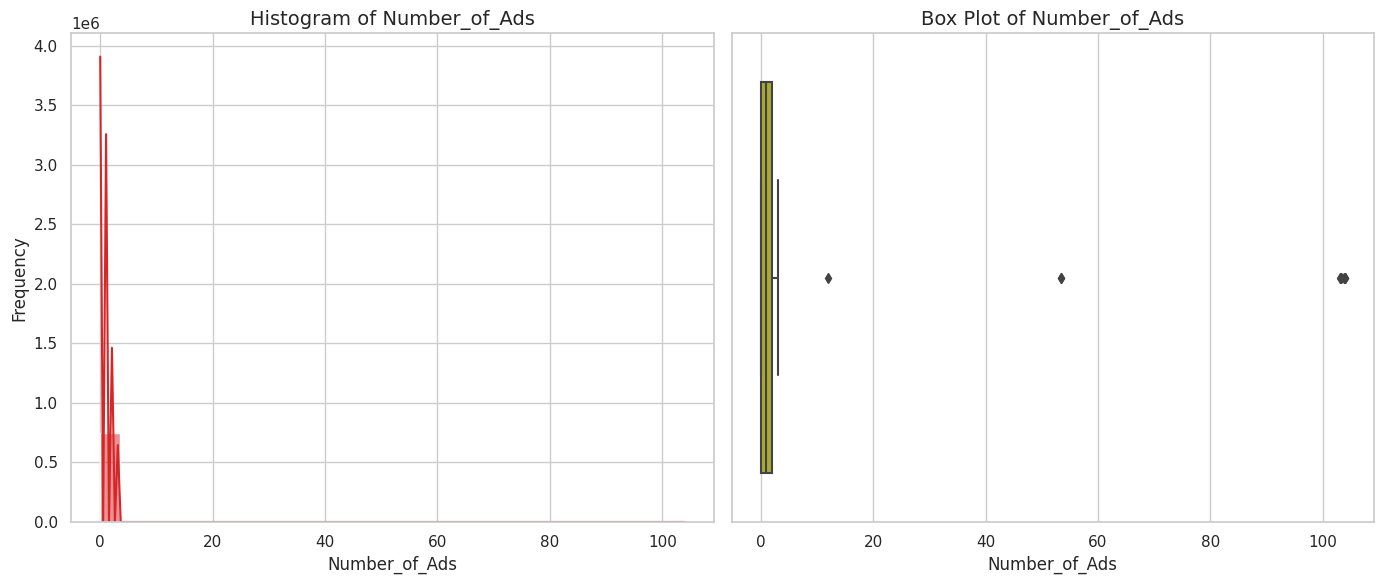


Statistics for Number_of_Ads:
Skewness: 6.03
Number of Missing Values: 1


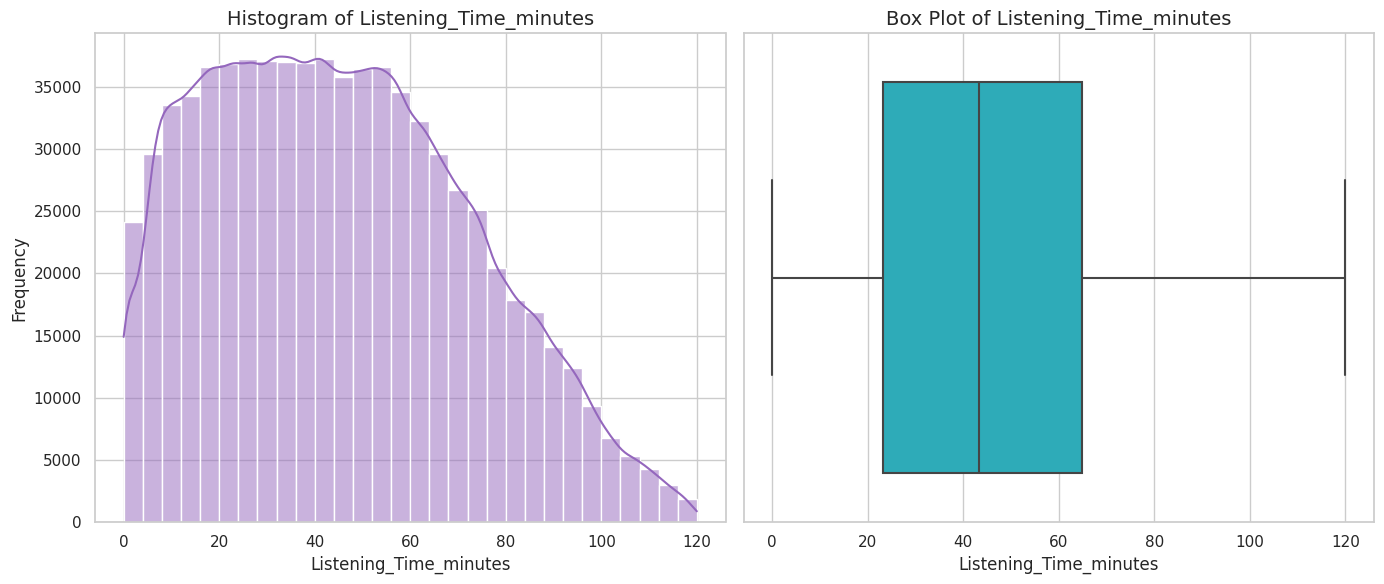


Statistics for Listening_Time_minutes:
Skewness: 0.35
Number of Missing Values: 0


In [33]:
numerical_features = [
    "Episode_Length_minutes",
    "Host_Popularity_percentage",
    "Guest_Popularity_percentage",
    "Number_of_Ads",
    "Listening_Time_minutes",
]

# Define custom colors for each plot
histogram_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
boxplot_colors = ["#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

# Plot histograms and box plots for each numerical feature
for idx, feature in enumerate(numerical_features):
    plt.figure(figsize=(14, 6))

    # Histogram with KDE (Kernel Density Estimate)
    plt.subplot(1, 2, 1)
    sns.histplot(train_df[feature], kde=True, bins=30, color=histogram_colors[idx])
    plt.title(f"Histogram of {feature}", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    # Box plot to identify outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_df[feature], color=boxplot_colors[idx])
    plt.title(f"Box Plot of {feature}", fontsize=14)

    plt.tight_layout()
    plt.show()

    # Print additional statistics
    print(f"\nStatistics for {feature}:")
    print(f"Skewness: {train_df[feature].skew():.2f}")
    print(f"Number of Missing Values: {train_df[feature].isnull().sum()}")

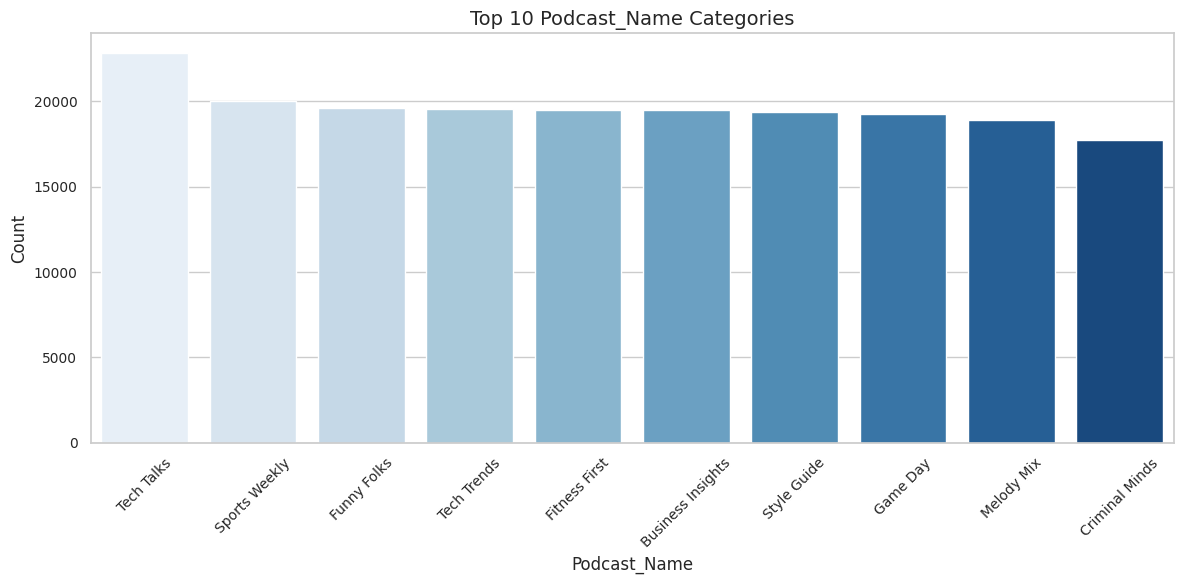

Number of Unique Podcast_Name: 48
Missing Values in Podcast_Name: 0


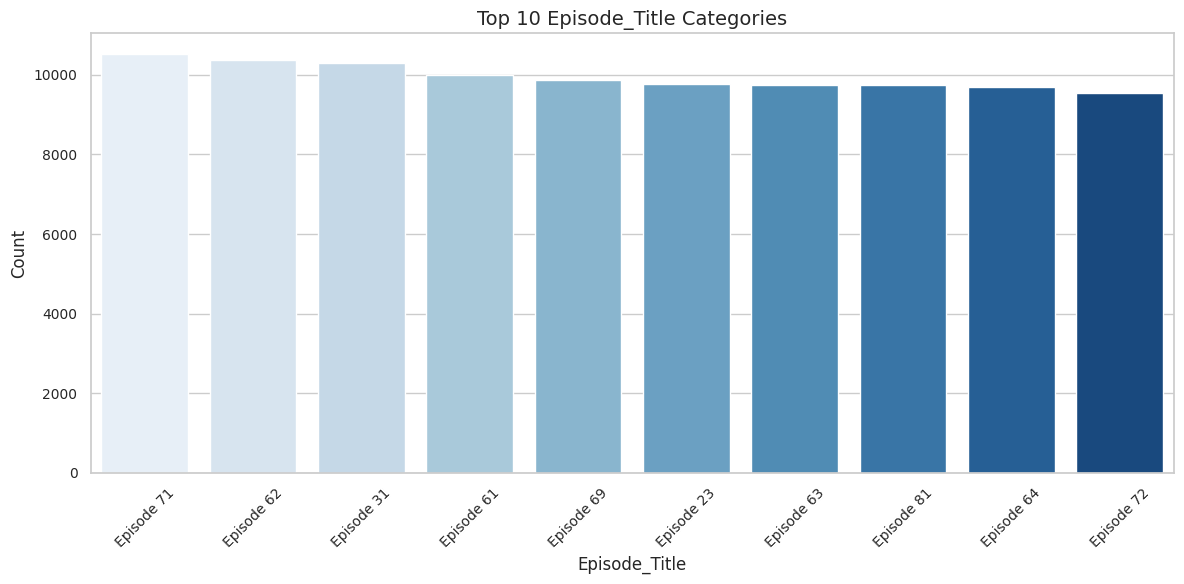

Number of Unique Episode_Title: 100
Missing Values in Episode_Title: 0


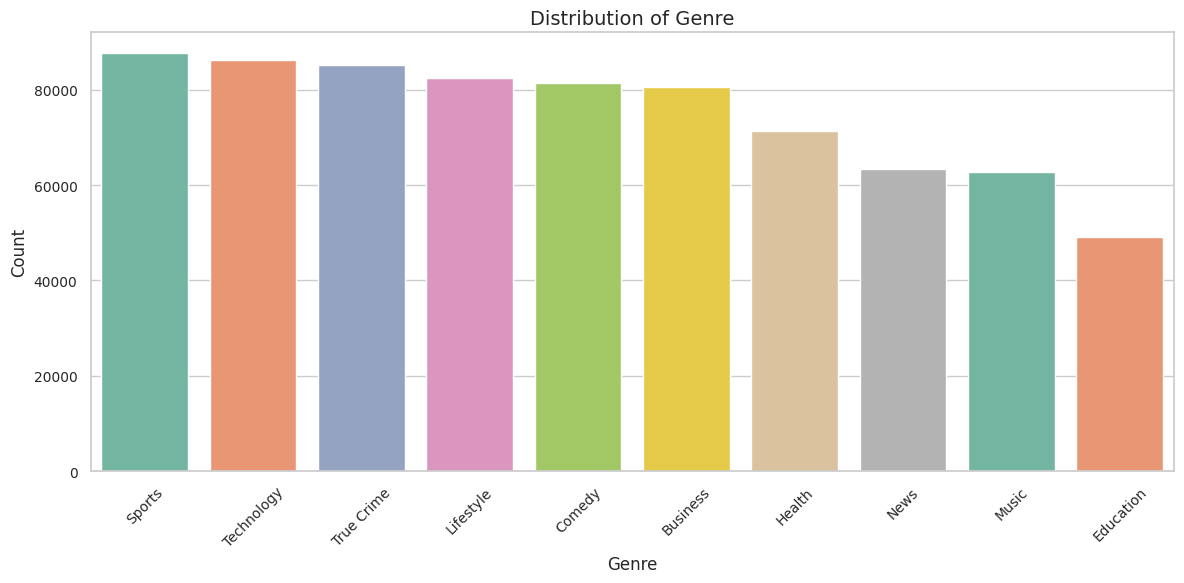

Number of Unique Genre: 10
Missing Values in Genre: 0


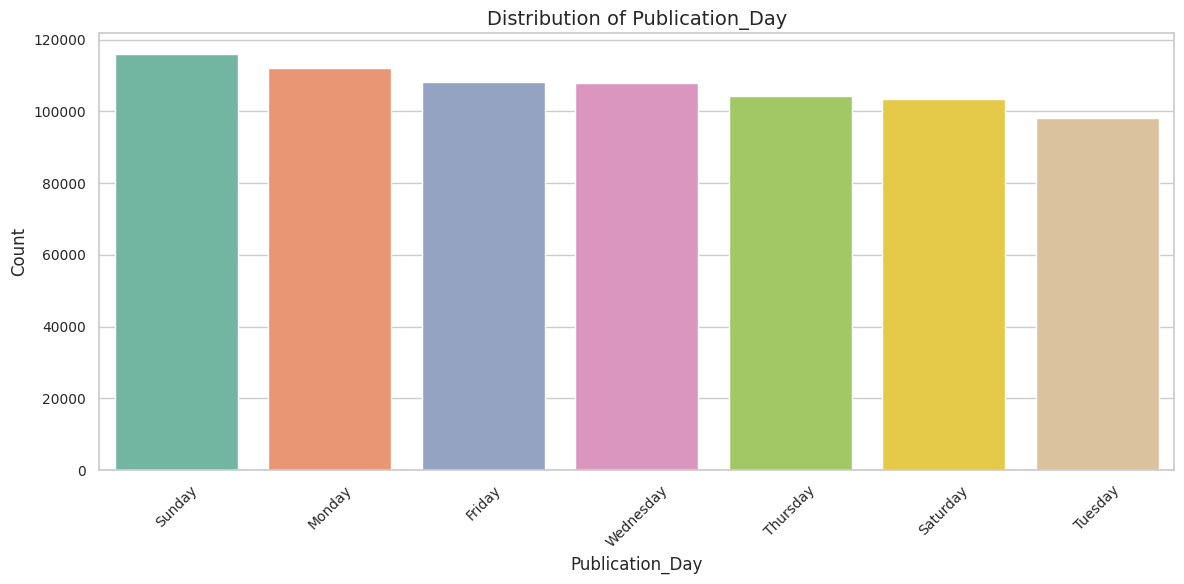

Number of Unique Publication_Day: 7
Missing Values in Publication_Day: 0


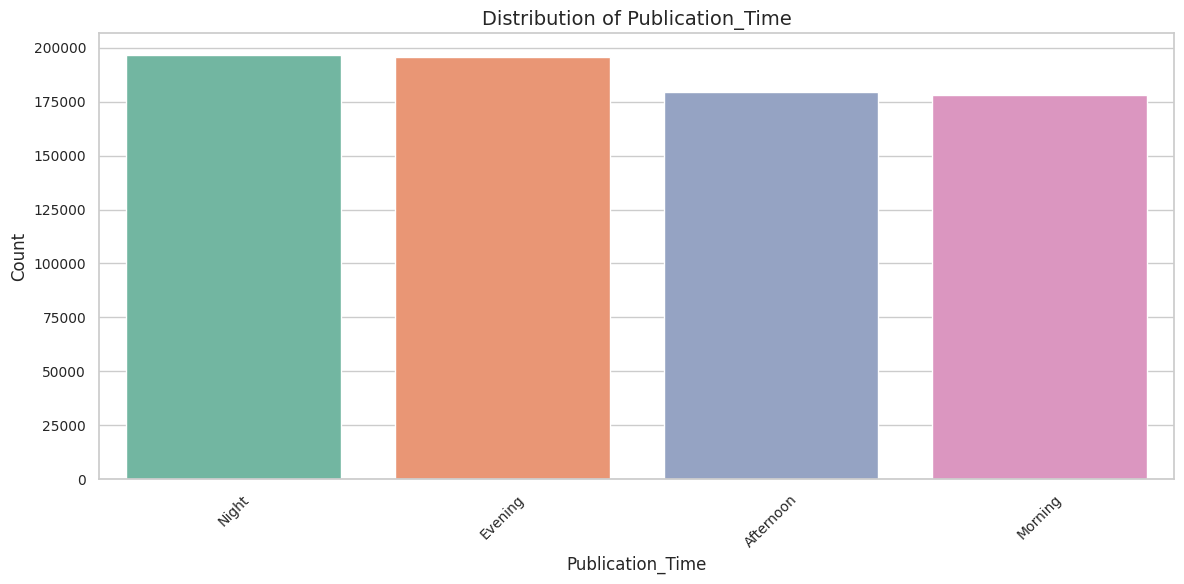

Number of Unique Publication_Time: 4
Missing Values in Publication_Time: 0


In [34]:
# Define the categorical features
categorical_features = [
    "Podcast_Name",
    "Episode_Title",
    "Genre",
    "Publication_Day",
    "Publication_Time",
]

# Define custom colors for the plots
bar_colors = sns.color_palette("Blues", 10)  # A range of blue colors for bar plots
countplot_colors = sns.color_palette("Set2", 8)  # A range of Set2 colors for count plots

# Plot bar charts for each categorical feature
for idx, feature in enumerate(categorical_features):
    plt.figure(figsize=(12, 6))

    if feature in ["Podcast_Name", "Episode_Title"]:
        # For features with many unique values, plot top 10 categories
        top_categories = train_df[feature].value_counts().nlargest(10)
        sns.barplot(x=top_categories.index, y=top_categories.values, palette=bar_colors)
        plt.title(f"Top 10 {feature} Categories", fontsize=14)
    else:
        # For features with fewer categories, plot all categories
        sns.countplot(
            x=train_df[feature], 
            order=train_df[feature].value_counts().index, 
            palette=countplot_colors
        )
        plt.title(f"Distribution of {feature}", fontsize=14)

    # Enhance labels and readability
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    # Print the number of unique values and missing values for each feature
    print(f"Number of Unique {feature}: {train_df[feature].nunique()}")
    print(f"Missing Values in {feature}: {train_df[feature].isnull().sum()}")

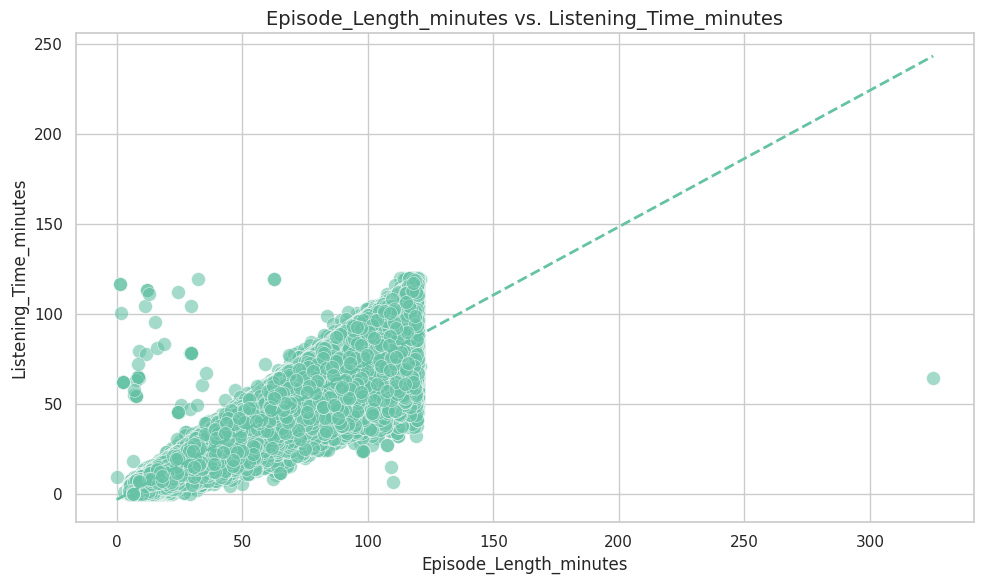

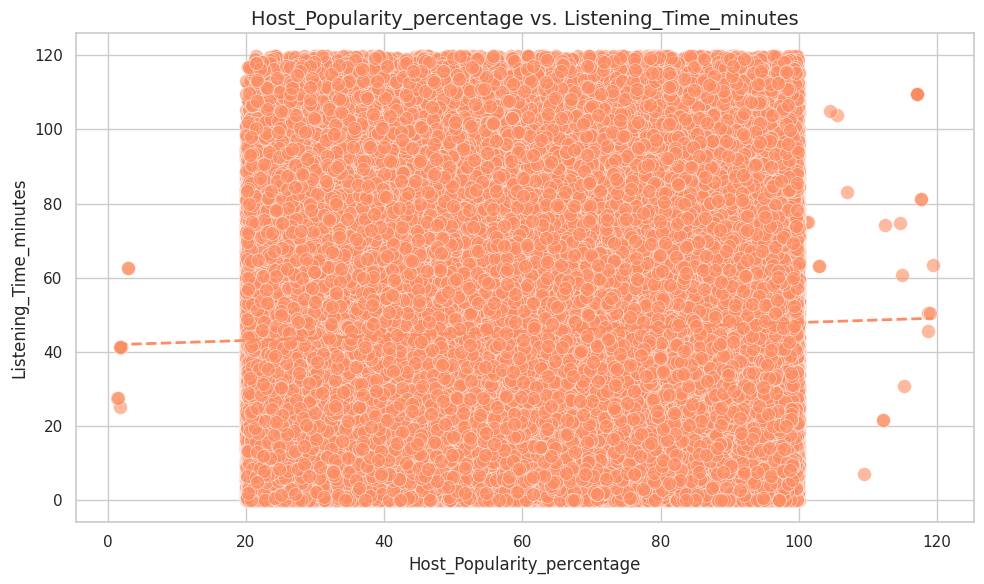

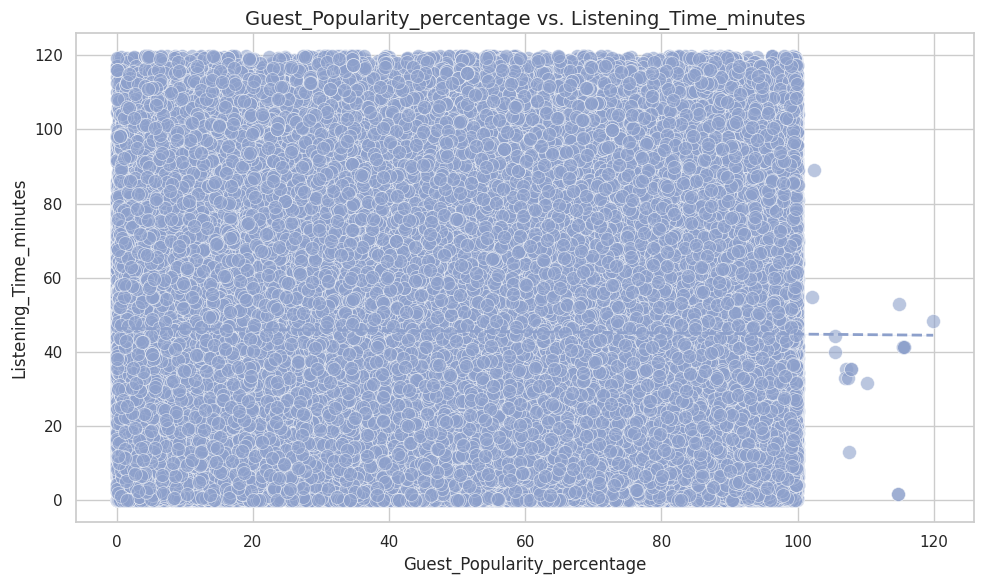

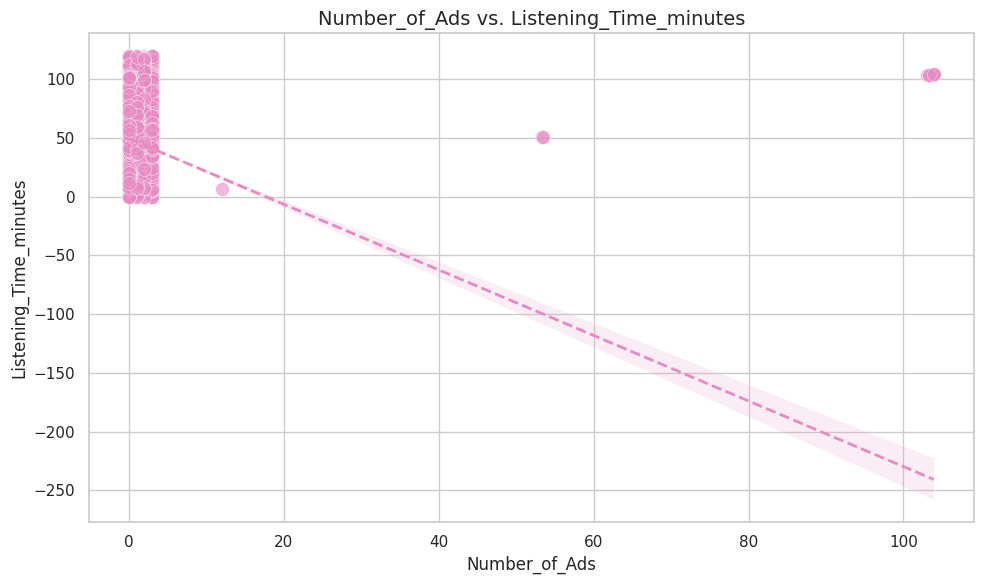

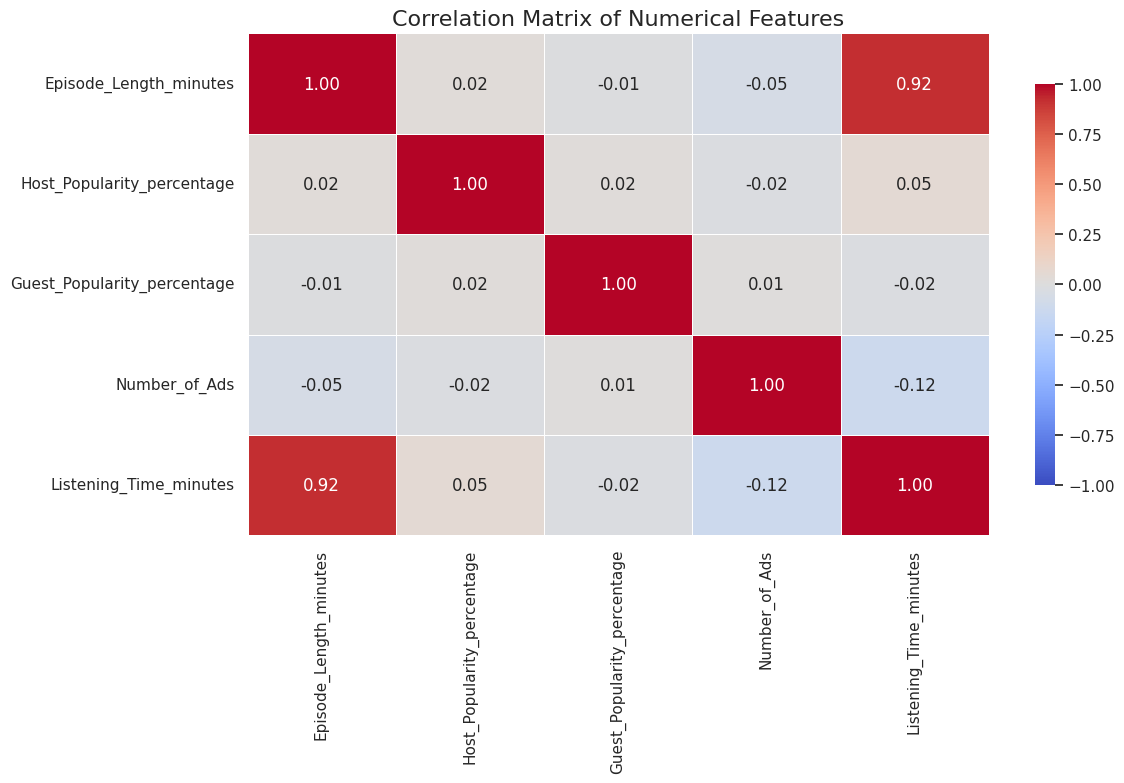

In [35]:
# Define numerical features
numerical_features = [
    "Episode_Length_minutes",
    "Host_Popularity_percentage",
    "Guest_Popularity_percentage",
    "Number_of_Ads",
    "Listening_Time_minutes",
]

# Scatter Plots with Unique Styling
for idx, feature in enumerate(numerical_features[:-1]):  # Exclude 'Listening_Time_minutes'
    plt.figure(figsize=(10, 6))
    
    # Use a distinct color palette for each scatter plot
    scatter_color = sns.color_palette("Set2", 8)[idx]
    
    sns.scatterplot(
        x=train_df[feature], y=train_df["Listening_Time_minutes"], 
        alpha=0.6, color=scatter_color, s=100, edgecolor="w", linewidth=0.5
    )
    
    # Add a linear regression line for insight
    sns.regplot(x=train_df[feature], y=train_df["Listening_Time_minutes"], scatter=False, 
                line_kws={"color": scatter_color, "linewidth": 2, "linestyle": "--"})
    
    plt.title(f"{feature} vs. Listening_Time_minutes", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Listening_Time_minutes", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Correlation Matrix with Custom Colors and Styling
correlation_matrix = train_df[numerical_features].corr()
plt.figure(figsize=(12, 8))

# Use a custom diverging color palette for better distinction
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", 
            vmin=-1, vmax=1, annot_kws={"size": 12}, cbar_kws={'shrink': 0.8}, linewidths=0.5)

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [36]:
from sklearn.impute import SimpleImputer

In [37]:
def check_missing_values(df):
    """Prints the missing values count for each column."""
    print("Missing Values per Column:")
    missing_values = df.isnull().sum()
    print(missing_values[missing_values > 0])  # Only display columns with missing values
    return missing_values

# Imputation function for both numerical and categorical features
def impute_missing_values(df, numerical_features, categorical_features):
    """Imputes missing values for numerical and categorical features."""
    
    # Impute numerical features with the median value
    print("\nImputing Numerical Features with Median...")
    num_imputer = SimpleImputer(strategy="median")
    df[numerical_features] = num_imputer.fit_transform(df[numerical_features])
    
    # Impute categorical features with the most frequent (mode) value
    print("Imputing Categorical Features with Mode...")
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])
    
    return df

if __name__ == "__main__":
    # Print missing values before imputation
    check_missing_values(train_df)
    
    # Impute the missing values in both numerical and categorical columns
    train_df = impute_missing_values(train_df, numerical_features, categorical_features)
    
    # Verify that no missing values remain after imputation
    print("\nMissing Values After Imputation:")
    check_missing_values(train_df)

Missing Values per Column:
Episode_Length_minutes          87093
Guest_Popularity_percentage    146030
Number_of_Ads                       1
dtype: int64

Imputing Numerical Features with Median...
Imputing Categorical Features with Mode...

Missing Values After Imputation:
Missing Values per Column:
Series([], dtype: int64)


In [38]:
print(train_df.isnull().sum())

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64


## Thank you...pls upvote!!!